In [1]:
import cv2
import numpy as np
from ultralytics import YOLO
import math
import pandas as pd
import pandas as pd
import numpy as np
import cv2
from scipy.optimize import linear_sum_assignment
import os
 

In [22]:


class EKFTracker:
    def __init__(self, initial_state, P, Q, R, dt):
        self.x = initial_state
        self.P = P
        self.Q = Q
        self.R = R
        self.dt = dt
        self.missed_frames = 0
        self.lost_age = 0
        self.H = np.array([[1, 0, 0, 0, 0], [0, 1, 0, 0, 0], [0, 0, 0, 0, 1]])

    def predict(self):
        F = np.eye(5)
        F[0, 2] = self.dt
        F[1, 3] = self.dt
        self.x = F @ self.x
        self.P = F @ self.P @ F.T + self.Q

    def update(self, z):
        z_pred = self.H @ self.x
        y = z - z_pred
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        self.x = self.x + K @ y
        self.P = (np.eye(len(self.x)) - K @ self.H) @ self.P
        self.missed_frames = 0

def data_association(trackers, detections, cost_threshold):
    if not trackers or not detections:
        return {}, set(trackers.keys()), set(range(len(detections)))

    tracker_ids = list(trackers.keys())
    pred_points = np.array([trackers[tid].x[:2, 0] for tid in tracker_ids])
    det_points = np.array([d['point'] for d in detections])
    
    cost_matrix = np.linalg.norm(pred_points[:, np.newaxis, :] - det_points[np.newaxis, :, :], axis=2)
    
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    
    matched, unmatched_tracker_ids, unmatched_detection_idxs = {}, set(tracker_ids), set(range(len(detections)))
    for r, c in zip(row_ind, col_ind):
        if cost_matrix[r, c] < cost_threshold:
            t_id = tracker_ids[r]
            matched[t_id] = detections[c]
            unmatched_tracker_ids.discard(t_id)
            unmatched_detection_idxs.discard(c)
            
    return matched, unmatched_tracker_ids, unmatched_detection_idxs

In [25]:
def run_single_camera_tracking(cam, model_name):
    SOURCE_VIDEO_PATH = f"../dataset/CarLA/Camera_{cam}/video/Camera_{cam}.mp4"
    OUTPUT_VIDEO_PATH = f"./outputs/Camera_{cam}/video/{model_name}_pred_with_gt.mp4"
    GT_PATH = f"../dataset/CarLA/Camera_{cam}/bboxes.csv"
    MODEL_PATH = f"../weights/{model_name}.pt"
    
    CONF_THRESHOLD = 0.9
    IOU_THRESHOLD = 0.5
    VEHICLE_CLASSES = [2, 3, 5, 6, 7, 8] if model_name == "yolov8s" else [0]
    ASSOCIATION_THRESHOLD = 100
    MAX_MISSED_FRAMES = 15
    
    try:
        gt_df = pd.read_csv(GT_PATH)
        gt_by_frame = gt_df.groupby('Frame')
    except FileNotFoundError:
        print(f"Ground truth file not found at {GT_PATH}. Will proceed without GT visualization.")
        gt_by_frame = None
    
    model = YOLO(MODEL_PATH)
    cap = cv2.VideoCapture(SOURCE_VIDEO_PATH)
    
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(OUTPUT_VIDEO_PATH, fourcc, fps, (frame_width, frame_height))
    
    results_file = open(f"./outputs/Camera_{cam}/{model_name}_results.txt", "w")
    
    active_trackers = {}
    next_tracker_id = 0
    frame_count = 0
    dt = 1 / fps if fps > 0 else 1/30
    
    P = np.eye(5) * 50
    Q = np.diag([10, 10, 50, 50, 10])
    R = np.diag([10, 10, 50])
    
    print("Processing video, saving results, and visualizing ground truth...")
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
    
        results = model(frame, conf=CONF_THRESHOLD, iou=IOU_THRESHOLD, classes=VEHICLE_CLASSES, verbose=False, device=0)
        detections = []
        for box in results[0].boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
            detections.append({'point': ((x1 + x2) // 2, (y1 + y2) // 2), 'bbox': (x1, y1, x2, y2)})
    
        for tracker in active_trackers.values(): tracker.predict()
        matched, unmatched_ids, unmatched_dets_indices = data_association(active_trackers, detections, ASSOCIATION_THRESHOLD)
        for tracker_id, detection in matched.items():
            active_trackers[tracker_id].update(np.array([detection['point'][0], detection['point'][1], 0]).reshape(3, 1))
        for tracker_id in list(unmatched_ids):
            tracker = active_trackers[tracker_id]
            tracker.missed_frames += 1
            if tracker.missed_frames > MAX_MISSED_FRAMES: del active_trackers[tracker_id]
        for idx in unmatched_dets_indices:
            detection = detections[idx]
            active_trackers[next_tracker_id] = EKFTracker(np.array([detection['point'][0], detection['point'][1], 0, 0, 0]).reshape(5, 1), P.copy(), Q.copy(), R.copy(), dt)
            next_tracker_id += 1
        
        if gt_by_frame is not None and frame_count in gt_by_frame.groups:
            gt_frame_data = gt_by_frame.get_group(frame_count)
            for index, row in gt_frame_data.iterrows():
                x1, y1, x2, y2 = int(row['min_x']), int(row['min_y']), int(row['max_x']), int(row['max_y'])
                center_x, center_y = (x1 + x2) // 2, (y1 + y2) // 2
                
                # Draw GT bounding box in RED
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 255), 2)
                # Draw GT centroid in RED
                cv2.circle(frame, (center_x, center_y), 4, (0, 0, 255), -1)
        
        for tracker_id, tracker in active_trackers.items():
            state = tracker.x
            pos = (int(state[0, 0]), int(state[1, 0]))
            
            result_line = f"{frame_count},{tracker_id},{pos[0]},{pos[1]},-1,-1,-1,-1\n"
            results_file.write(result_line)
    
            cv2.putText(frame, str(tracker_id), (pos[0], pos[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
            cv2.circle(frame, pos, 4, (0, 255, 0), -1)
    
        out.write(frame)
        frame_count += 1
    
    cap.release()
    out.release()
    results_file.close()
    cv2.destroyAllWindows()
    print(f"{cam} Processing complete.")

for model_name in ["yolov8s", "yolov8s_custom_300e", "300_best", "yolo11m_custom_300e"]:
    for cam_id in [1, 2, 3]:
        run_single_camera_tracking(cam_id, model_name)

Processing video, saving results, and visualizing ground truth...
1 Processing complete.
Processing video, saving results, and visualizing ground truth...
2 Processing complete.
Processing video, saving results, and visualizing ground truth...
3 Processing complete.
Processing video, saving results, and visualizing ground truth...
1 Processing complete.
Processing video, saving results, and visualizing ground truth...
2 Processing complete.
Processing video, saving results, and visualizing ground truth...
3 Processing complete.
Processing video, saving results, and visualizing ground truth...
1 Processing complete.
Processing video, saving results, and visualizing ground truth...
2 Processing complete.
Processing video, saving results, and visualizing ground truth...
3 Processing complete.
Processing video, saving results, and visualizing ground truth...
1 Processing complete.
Processing video, saving results, and visualizing ground truth...
2 Processing complete.
Processing video, sav

# Evaluate the tracking results against ground-truth 

In [2]:
def load_roi_from_file(path):
    """Loads a list of (x, y) coordinates from a text file."""
    try:
        points = []
        with open(path, "r") as f:
            for line in f:
                parts = line.strip().split(',')
                if len(parts) == 2:
                    points.append((int(parts[0]), int(parts[1])))
        if not points:
            print(f"Warning: No valid points found in ROI file '{path}'.")
            return None
        return np.array(points, dtype=np.int32)
    except FileNotFoundError:
        print(f"Warning: ROI file not found at '{path}'. Proceeding without ROI filtering.")
        return None
    except ValueError:
        print(f"Error: Could not parse points in ROI file '{path}'. Ensure format is 'x,y' per line.")
        return None

def load_ground_truth_centroids(path, roi_polygon=None):
    if not os.path.exists(path):
        print(f"  Error: Ground truth file not found at '{path}'. Cannot load GT.")
        return pd.DataFrame()

    df = pd.read_csv(path)
    df['center_x'] = (df['min_x'] + df['max_x']) / 2
    df['center_y'] = (df['min_y'] + df['max_y']) / 2
    df.rename(columns={'Frame': 'FrameId', 'Vehicle_ID': 'Id'}, inplace=True)

    if roi_polygon is not None:
        initial_count = len(df)
        try:
            df['is_in_roi'] = df.apply(
                lambda row: cv2.pointPolygonTest(
                    roi_polygon, (float(row['center_x']), float(row['center_y'])), False
                ) >= 0, axis=1
            )
            df = df[df['is_in_roi']].drop(columns=['is_in_roi'])
            print(f"  Filtered GT: Kept {len(df)} of {initial_count} objects within ROI.")
        except Exception as e:
            print(f"  Error during GT ROI filtering: {e}. Proceeding without filtering GT.")
    else:
         print("  No ROI provided for GT filtering.")

    return df

def load_predictions_centroids(path, roi_polygon=None):
    """Loads predicted centroids and optionally filters them using an ROI."""
    if not os.path.exists(path):
        print(f"  Error: Prediction file not found at '{path}'. Cannot load predictions.")
        return pd.DataFrame()

    df = pd.read_csv(path, header=None)
    df.columns = ['FrameId', 'Id', 'center_x', 'center_y', 'c5', 'c6', 'c7', 'c8']

    if roi_polygon is not None:
        initial_count = len(df)
        try:
            df['is_in_roi'] = df.apply(
                lambda row: cv2.pointPolygonTest(
                    roi_polygon, (float(row['center_x']), float(row['center_y'])), False
                ) >= 0, axis=1
            )
            df = df[df['is_in_roi']].drop(columns=['is_in_roi'])
            print(f"  Filtered Pred: Kept {len(df)} of {initial_count} predictions within ROI.")
        except Exception as e:
            print(f"  Error during Pred ROI filtering: {e}. Proceeding without filtering predictions.")
    else:
        print("  No ROI provided for Pred filtering.")

    return df

def evaluate_tracking(gt_df, ts_df, distance_threshold=50):
    """Evaluates tracking performance using a distance-based method."""
    try:
        # Check if DataFrames are empty AFTER filtering
        if gt_df.empty:
             print("  Ground truth DataFrame is empty after filtering. Cannot evaluate.")
             return {
                 "Total GT (ROI)": 0, "Matches": 0, "Matches (%)": "0.0%", "Misses": 0,
                 "Misses (%)": "0.0%", "False Alarms": len(ts_df), "ID Switches": 0, "MOTP (px)": "0.00"
             }

        total_gt_objects = len(gt_df)

        gt_by_frame = gt_df.groupby('FrameId')
        ts_by_frame = ts_df.groupby('FrameId')

        matches, misses, false_alarms, id_switches, total_distance = 0, 0, 0, 0, 0.0
        gt_track_history = {}

        max_frame = 0
        if not gt_df.empty: max_frame = max(max_frame, int(gt_df['FrameId'].max()))
        if not ts_df.empty: max_frame = max(max_frame, int(ts_df['FrameId'].max()))

        for frame_id in range(max_frame + 1):
            gt_frame = gt_by_frame.get_group(frame_id) if frame_id in gt_by_frame.groups else pd.DataFrame()
            ts_frame = ts_by_frame.get_group(frame_id) if frame_id in ts_by_frame.groups else pd.DataFrame()

            if gt_frame.empty and ts_frame.empty: continue
            if gt_frame.empty:
                false_alarms += len(ts_frame)
                continue
            if ts_frame.empty:
                misses += len(gt_frame)
                continue

            gt_points = gt_frame[['center_x', 'center_y']].values
            ts_points = ts_frame[['center_x', 'center_y']].values
            cost_matrix = np.linalg.norm(gt_points[:, np.newaxis, :] - ts_points[np.newaxis, :, :], axis=2)
            gt_ind, ts_ind = linear_sum_assignment(cost_matrix)

            matched_gt_indices, matched_ts_indices = set(), set()
            for r, c in zip(gt_ind, ts_ind):
                if cost_matrix[r, c] < distance_threshold:
                    matches += 1
                    gt_id = gt_frame.iloc[r]['Id']
                    ts_id = ts_frame.iloc[c]['Id']
                    if gt_id in gt_track_history and gt_track_history[gt_id] != ts_id:
                        id_switches += 1
                    gt_track_history[gt_id] = ts_id
                    total_distance += cost_matrix[r, c]
                    matched_gt_indices.add(r)
                    matched_ts_indices.add(c)
            misses += len(gt_points) - len(matched_gt_indices)
            false_alarms += len(ts_points) - len(matched_ts_indices)

        motp = total_distance / matches if matches > 0 else 0.0

        return {
            "Total GT (ROI)": total_gt_objects,
            "Matches": matches,
            "Matches (%)": f"{matches / total_gt_objects:.1%}",
            "Misses": misses,
            "Misses (%)": f"{misses / total_gt_objects:.1%}",
            "False Alarms": false_alarms,
            "ID Switches": id_switches,
            "MOTP (px)": f"{motp:.2f}"
        }

    except Exception as e:
        print(f"\nAn unexpected error occurred during evaluation: {e}")
        return None


In [4]:
base_data_path = "../dataset/CarLA"
camera_ids = [1, 2, 3]
thresholds_to_test = [10, 25, 50]

results_data = []

for model_name in ["yolov8s", "yolov8s_custom_300e", "300_best", "yolo11m_custom_300e"]:
    print(f"\n=== Evaluating Model: {model_name} ===")
    for cam_id in camera_ids:
        print(f"\n--- Evaluating Camera {cam_id} ---")
        
        cam_folder = f"Camera_{cam_id}"
        gt_file = os.path.join(base_data_path, cam_folder, "bboxes.csv")
        roi_file = os.path.join(base_data_path, cam_folder, "roi_coords.txt")
        pred_file = os.path.join("./outputs", cam_folder, f"{model_name}_results.txt")
    
        roi_polygon = load_roi_from_file(roi_file)
        if roi_polygon is None:
            print(f"Skipping Camera {cam_id} due to missing or invalid ROI file.")
            continue
    
        gt_df_filtered = load_ground_truth_centroids(gt_file, roi_polygon)
        ts_df_filtered = load_predictions_centroids(pred_file, roi_polygon)
    
        if gt_df_filtered.empty and ts_df_filtered.empty:
            print(f"Skipping Camera {cam_id} - Both GT and Prediction data are empty after filtering or file read error.")
            continue
        elif gt_df_filtered.empty:
             print(f"Warning for Camera {cam_id}: Ground truth data is empty after filtering.")
        elif ts_df_filtered.empty:
             print(f"Warning for Camera {cam_id}: Prediction data is empty after filtering.")
    
    
        for threshold in thresholds_to_test:
            print(f"\nRunning evaluation with threshold = {threshold}px.")
            metrics = evaluate_tracking(gt_df_filtered.copy(), ts_df_filtered.copy(), distance_threshold=threshold)
    
            if metrics:
                row_data = {
                    "Camera": cam_id,
                    "Threshold (px)": threshold,
                    "Total GT (ROI)": metrics["Total GT (ROI)"],
                    "Matches": metrics["Matches"],
                    "Matches (%)": metrics["Matches (%)"],
                    "Misses": metrics["Misses"],
                    "Misses (%)": metrics["Misses (%)"],
                    "False Alarms": metrics["False Alarms"],
                    "ID Switches": metrics["ID Switches"],
                    "MOTP (px)": metrics["MOTP (px)"]
                }
                results_data.append(row_data)
            else:
                 print(f"Evaluation failed for Camera {cam_id} at threshold {threshold}px.")
    
    
    if results_data:
        results_df = pd.DataFrame(results_data)
        print(f"\n\n--- Combined Evaluation Results for {model_name} ---")
        column_order = [
            "Camera", "Threshold (px)", "Total GT (ROI)", "Matches", "Matches (%)",
            "Misses", "Misses (%)", "False Alarms", "ID Switches", "MOTP (px)"
        ]
        results_df = results_df.reindex(columns=column_order, fill_value='N/A')
        print(results_df.to_string(index=False))
    else:
        print("\nNo evaluation results generated.")


=== Evaluating Model: yolov8s ===

--- Evaluating Camera 1 ---
  Filtered GT: Kept 2732 of 3072 objects within ROI.
  Filtered Pred: Kept 199 of 199 predictions within ROI.

Running evaluation with threshold = 10px.

Running evaluation with threshold = 25px.

Running evaluation with threshold = 50px.

--- Evaluating Camera 2 ---
  Filtered GT: Kept 7954 of 9474 objects within ROI.
  Filtered Pred: Kept 82 of 82 predictions within ROI.

Running evaluation with threshold = 10px.

Running evaluation with threshold = 25px.

Running evaluation with threshold = 50px.

--- Evaluating Camera 3 ---
  Filtered GT: Kept 5293 of 7039 objects within ROI.
  Filtered Pred: Kept 135 of 135 predictions within ROI.

Running evaluation with threshold = 10px.

Running evaluation with threshold = 25px.

Running evaluation with threshold = 50px.


--- Combined Evaluation Results for yolov8s ---
 Camera  Threshold (px)  Total GT (ROI)  Matches Matches (%)  Misses Misses (%)  False Alarms  ID Switches MOTP (

In [60]:
base_data_path = "../dataset/CarLA"
camera_ids = [1, 2, 3]
thresholds_to_test = [10, 25, 50]

results_data = []

for cam_id in camera_ids:
    print(f"\n--- Evaluating Camera {cam_id} ---")
    
    cam_folder = f"Camera_{cam_id}"
    gt_file = os.path.join(base_data_path, cam_folder, "bboxes.csv")
    roi_file = os.path.join(base_data_path, cam_folder, "roi_coords.txt")
    pred_file = os.path.join(base_data_path, cam_folder, "custom_single_camera_results.txt")

    roi_polygon = load_roi_from_file(roi_file)
    if roi_polygon is None:
        print(f"Skipping Camera {cam_id} due to missing or invalid ROI file.")
        continue

    gt_df_filtered = load_ground_truth_centroids(gt_file, roi_polygon)
    ts_df_filtered = load_predictions_centroids(pred_file, roi_polygon)

    if gt_df_filtered.empty and ts_df_filtered.empty:
        print(f"Skipping Camera {cam_id} - Both GT and Prediction data are empty after filtering or file read error.")
        continue
    elif gt_df_filtered.empty:
         print(f"Warning for Camera {cam_id}: Ground truth data is empty after filtering.")
    elif ts_df_filtered.empty:
         print(f"Warning for Camera {cam_id}: Prediction data is empty after filtering.")


    for threshold in thresholds_to_test:
        print(f"\nRunning evaluation with threshold = {threshold}px.")
        metrics = evaluate_tracking(gt_df_filtered.copy(), ts_df_filtered.copy(), distance_threshold=threshold)

        if metrics:
            row_data = {
                "Camera": cam_id,
                "Threshold (px)": threshold,
                "Total GT (ROI)": metrics["Total GT (ROI)"],
                "Matches": metrics["Matches"],
                "Matches (%)": metrics["Matches (%)"],
                "Misses": metrics["Misses"],
                "Misses (%)": metrics["Misses (%)"],
                "False Alarms": metrics["False Alarms"],
                "ID Switches": metrics["ID Switches"],
                "MOTP (px)": metrics["MOTP (px)"]
            }
            results_data.append(row_data)
        else:
             print(f"Evaluation failed for Camera {cam_id} at threshold {threshold}px.")


if results_data:
    results_df = pd.DataFrame(results_data)
    print("\n\n--- Combined Evaluation Results ---")
    column_order = [
        "Camera", "Threshold (px)", "Total GT (ROI)", "Matches", "Matches (%)",
        "Misses", "Misses (%)", "False Alarms", "ID Switches", "MOTP (px)"
    ]
    results_df = results_df.reindex(columns=column_order, fill_value='N/A')
    print(results_df.to_string(index=False))
else:
    print("\nNo evaluation results generated.")


--- Evaluating Camera 1 ---
  Filtered GT: Kept 2732 of 3072 objects within ROI.
  Filtered Pred: Kept 3067 of 3223 predictions within ROI.

Running evaluation with threshold = 10px.

Running evaluation with threshold = 25px.

Running evaluation with threshold = 50px.

--- Evaluating Camera 2 ---
  Filtered GT: Kept 7954 of 9474 objects within ROI.
  Filtered Pred: Kept 8060 of 8938 predictions within ROI.

Running evaluation with threshold = 10px.

Running evaluation with threshold = 25px.

Running evaluation with threshold = 50px.

--- Evaluating Camera 3 ---
  Filtered GT: Kept 5293 of 7039 objects within ROI.
  Filtered Pred: Kept 4870 of 5904 predictions within ROI.

Running evaluation with threshold = 10px.

Running evaluation with threshold = 25px.

Running evaluation with threshold = 50px.


--- Combined Evaluation Results ---
 Camera  Threshold (px)  Total GT (ROI)  Matches Matches (%)  Misses Misses (%)  False Alarms  ID Switches MOTP (px)
      1              10            

In [1]:
import pandas as pd
import numpy as np
import cv2
from scipy.optimize import linear_sum_assignment
import os
import matplotlib.pyplot as plt # Added for plotting

# --- Evaluation Functions ---

def load_roi_from_file(path):
    """Loads a list of (x, y) coordinates from a text file."""
    try:
        points = []
        with open(path, "r") as f:
            for line in f:
                parts = line.strip().split(',')
                if len(parts) == 2:
                    points.append((int(parts[0]), int(parts[1])))
        if not points:
            print(f"Warning: No valid points found in ROI file '{path}'.")
            return None
        return np.array(points, dtype=np.int32)
    except FileNotFoundError:
        print(f"Warning: ROI file not found at '{path}'. Proceeding without ROI filtering.")
        return None
    except ValueError:
        print(f"Error: Could not parse points in ROI file '{path}'. Ensure format is 'x,y' per line.")
        return None

def load_ground_truth_centroids(path, roi_polygon=None):
    """Loads GT bboxes, calculates centroids, and optionally filters them using an ROI."""
    if not os.path.exists(path):
        print(f"  Error: Ground truth file not found at '{path}'. Cannot load GT.")
        return pd.DataFrame() 

    df = pd.read_csv(path)
    df['center_x'] = (df['min_x'] + df['max_x']) / 2
    df['center_y'] = (df['min_y'] + df['max_y']) / 2
    df.rename(columns={'Frame': 'FrameId', 'Vehicle_ID': 'Id'}, inplace=True)

    if roi_polygon is not None:
        initial_count = len(df)
        try:
            df['is_in_roi'] = df.apply(
                lambda row: cv2.pointPolygonTest(
                    roi_polygon, (float(row['center_x']), float(row['center_y'])), False
                ) >= 0, axis=1
            )
            df = df[df['is_in_roi']].drop(columns=['is_in_roi'])
            print(f"  Filtered GT: Kept {len(df)} of {initial_count} objects within ROI.")
        except Exception as e:
            print(f"  Error during GT ROI filtering: {e}. Proceeding without filtering GT.")
    else:
         print("  No ROI provided for GT filtering.")

    return df

def load_predictions_centroids(path, roi_polygon=None):
    """Loads predicted centroids and optionally filters them using an ROI."""
    if not os.path.exists(path):
        print(f"  Error: Prediction file not found at '{path}'. Cannot load predictions.")
        return pd.DataFrame() 

    df = pd.read_csv(path, header=None)
    df.columns = ['FrameId', 'Id', 'center_x', 'center_y', 'c5', 'c6', 'c7', 'c8']

    if roi_polygon is not None:
        initial_count = len(df)
        try:
            df['is_in_roi'] = df.apply(
                lambda row: cv2.pointPolygonTest(
                    roi_polygon, (float(row['center_x']), float(row['center_y'])), False
                ) >= 0, axis=1
            )
            df = df[df['is_in_roi']].drop(columns=['is_in_roi'])
            print(f"  Filtered Pred: Kept {len(df)} of {initial_count} predictions within ROI.")
        except Exception as e:
            print(f"  Error during Pred ROI filtering: {e}. Proceeding without filtering predictions.")
    else:
        print("  No ROI provided for Pred filtering.")

    return df

def evaluate_tracking(gt_df, ts_df, distance_threshold=50):
    """Evaluates tracking performance and returns metrics AND match distances."""
    try:
        if gt_df.empty:
             print("  Ground truth DataFrame is empty. Cannot evaluate.")
             return None, []

        total_gt_objects = len(gt_df)
        gt_by_frame = gt_df.groupby('FrameId')
        ts_by_frame = ts_df.groupby('FrameId')

        matches, misses, false_alarms, id_switches = 0, 0, 0, 0
        match_distances = [] # <-- MODIFICATION: Store individual distances
        gt_track_history = {}

        max_frame = 0
        if not gt_df.empty: max_frame = max(max_frame, int(gt_df['FrameId'].max()))
        if not ts_df.empty: max_frame = max(max_frame, int(ts_df['FrameId'].max()))

        for frame_id in range(max_frame + 1):
            gt_frame = gt_by_frame.get_group(frame_id) if frame_id in gt_by_frame.groups else pd.DataFrame()
            ts_frame = ts_by_frame.get_group(frame_id) if frame_id in ts_by_frame.groups else pd.DataFrame()

            if gt_frame.empty and ts_frame.empty: continue
            if gt_frame.empty:
                false_alarms += len(ts_frame)
                continue
            if ts_frame.empty:
                misses += len(gt_frame)
                continue

            gt_points = gt_frame[['center_x', 'center_y']].values
            ts_points = ts_frame[['center_x', 'center_y']].values
            cost_matrix = np.linalg.norm(gt_points[:, np.newaxis, :] - ts_points[np.newaxis, :, :], axis=2)
            gt_ind, ts_ind = linear_sum_assignment(cost_matrix)

            matched_gt_indices, matched_ts_indices = set(), set()
            for r, c in zip(gt_ind, ts_ind):
                if cost_matrix[r, c] < distance_threshold:
                    matches += 1
                    gt_id = gt_frame.iloc[r]['Id']
                    ts_id = ts_frame.iloc[c]['Id']
                    if gt_id in gt_track_history and gt_track_history[gt_id] != ts_id:
                        id_switches += 1
                    gt_track_history[gt_id] = ts_id
                    
                    match_distances.append(cost_matrix[r, c]) # <-- MODIFICATION: Store distance
                    
                    matched_gt_indices.add(r)
                    matched_ts_indices.add(c)
            misses += len(gt_points) - len(matched_gt_indices)
            false_alarms += len(ts_points) - len(matched_ts_indices)

        motp = np.mean(match_distances) if matches > 0 else 0.0

        metrics = {
            "Total GT (ROI)": total_gt_objects,
            "Matches": matches,
            "Matches (%)": f"{matches / total_gt_objects:.1%}",
            "Misses": misses,
            "Misses (%)": f"{misses / total_gt_objects:.1%}",
            "False Alarms": false_alarms,
            "ID Switches": id_switches,
            "MOTP (px)": f"{motp:.2f}"
        }
        
        return metrics, match_distances # <-- MODIFICATION: Return distances

    except Exception as e:
        print(f"\nAn unexpected error occurred during evaluation: {e}")
        return None, []



--- Evaluating Camera 1 ---
  Filtered GT: Kept 2732 of 3072 objects within ROI.
  Filtered Pred: Kept 3067 of 3223 predictions within ROI.

Running evaluation with threshold = 10px...

Running evaluation with threshold = 25px...

Running evaluation with threshold = 50px...

--- Evaluating Camera 2 ---
  Filtered GT: Kept 7954 of 9474 objects within ROI.
  Filtered Pred: Kept 8060 of 8938 predictions within ROI.

Running evaluation with threshold = 10px...

Running evaluation with threshold = 25px...

Running evaluation with threshold = 50px...

--- Evaluating Camera 3 ---
  Filtered GT: Kept 5293 of 7039 objects within ROI.
  Filtered Pred: Kept 4870 of 5904 predictions within ROI.

Running evaluation with threshold = 10px...

Running evaluation with threshold = 25px...

Running evaluation with threshold = 50px...


--- Combined Evaluation Results ---
 Camera  Threshold (px)  Total GT (ROI)  Matches Matches (%)  Misses Misses (%)  False Alarms  ID Switches MOTP (px)
      1          

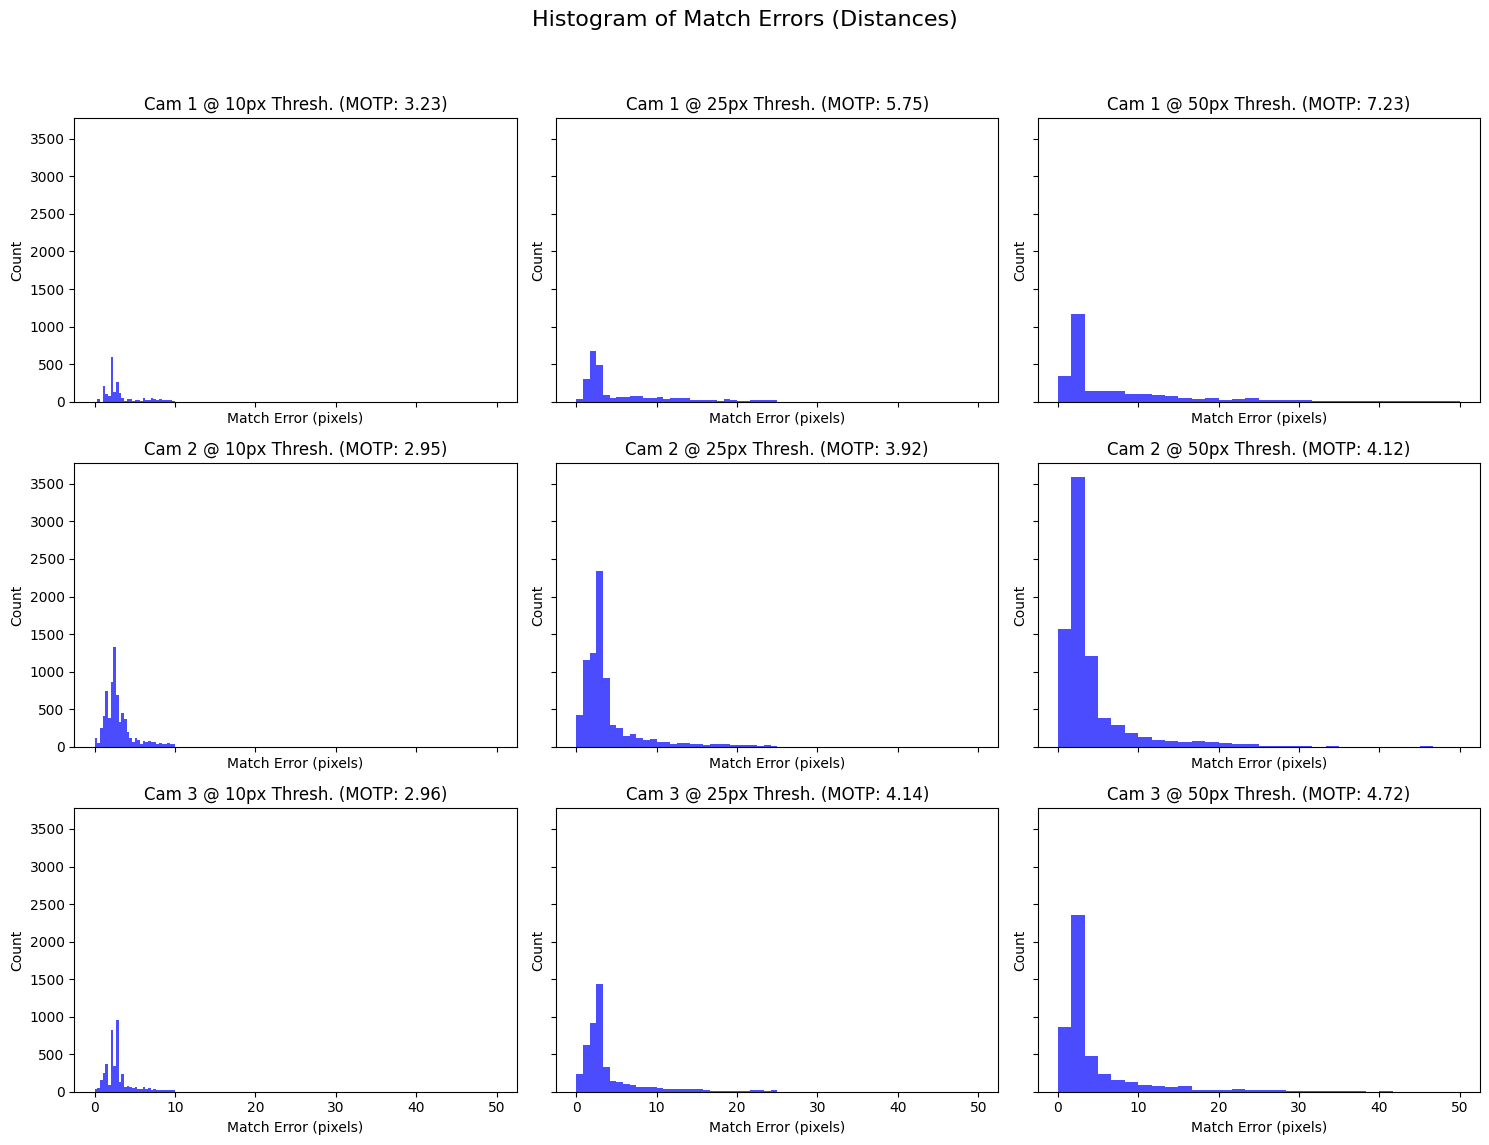

In [2]:
base_data_path = "../dataset/CarLA"
camera_ids = [1, 2, 3]
thresholds_to_test = [10, 25, 50]

results_data = [] 
all_match_histories = {}

for cam_id in camera_ids:
    print(f"\n--- Evaluating Camera {cam_id} ---")
    cam_folder = f"Camera_{cam_id}"
    
    gt_file = os.path.join(base_data_path, cam_folder, "bboxes.csv")
    roi_file = os.path.join(base_data_path, cam_folder, "roi_coords.txt")
    pred_file = os.path.join(base_data_path, cam_folder, "custom_single_camera_results.txt")

    roi_polygon = load_roi_from_file(roi_file)
    if roi_polygon is None:
        print(f"Skipping Camera {cam_id} due to missing or invalid ROI file.")
        continue

    gt_df_filtered = load_ground_truth_centroids(gt_file, roi_polygon)
    ts_df_filtered = load_predictions_centroids(pred_file, roi_polygon)

    if gt_df_filtered.empty and ts_df_filtered.empty:
        print(f"Skipping Camera {cam_id} - Both GT and Prediction data are empty.")
        continue
        
    for threshold in thresholds_to_test:
        print(f"\nRunning evaluation with threshold = {threshold}px...")
        
        # --- MODIFICATION: Get both metrics and distances ---
        metrics, distances = evaluate_tracking(gt_df_filtered.copy(), ts_df_filtered.copy(), distance_threshold=threshold)
        
        if metrics:
            row_data = {"Camera": cam_id, "Threshold (px)": threshold, **metrics}
            results_data.append(row_data)
            
            # --- NEW: Store the distances for plotting ---
            all_match_histories[(cam_id, threshold)] = distances
        else:
             print(f"Evaluation failed for Camera {cam_id} at threshold {threshold}px.")

# --- Display Results Table ---
if results_data:
    results_df = pd.DataFrame(results_data)
    print("\n\n--- Combined Evaluation Results ---")
    column_order = [
        "Camera", "Threshold (px)", "Total GT (ROI)", "Matches", "Matches (%)",
        "Misses", "Misses (%)", "False Alarms", "ID Switches", "MOTP (px)"
    ]
    results_df = results_df.reindex(columns=column_order, fill_value='N/A')
    print(results_df.to_string(index=False))
else:
    print("\nNo evaluation results generated.")
    
# --- NEW: Plotting Histograms ---
if all_match_histories:
    print("\nGenerating match error histograms...")
    fig, axes = plt.subplots(len(camera_ids), len(thresholds_to_test), 
                             figsize=(15, 12), sharex=True, sharey=True)
    fig.suptitle("Histogram of Match Errors (Distances)", fontsize=16)
    
    for i, cam_id in enumerate(camera_ids):
        for j, threshold in enumerate(thresholds_to_test):
            ax = axes[i, j]
            key = (cam_id, threshold)
            
            if key in all_match_histories and all_match_histories[key]:
                distances = all_match_histories[key]
                # Plot histogram of errors, range is 0 to the threshold
                ax.hist(distances, bins=30, range=(0, threshold), color='blue', alpha=0.7)
                ax.set_title(f"Cam {cam_id} @ {threshold}px Thresh. (MOTP: {np.mean(distances):.2f})")
                ax.set_xlabel("Match Error (pixels)")
                ax.set_ylabel("Count")
            else:
                ax.set_title(f"Cam {cam_id} @ {threshold}px Thresh. (No Matches)")
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("match_error_histograms.png")
    print(f"Successfully saved histograms to 'match_error_histograms.png'")